# Tasks

In [3]:
# imports 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# Task 1 — Convolution Mechanics: Filters and Shapes


#### Part A — Handcrafted filters.



In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

img, label = dataset[0]

# (3, 32, 32) → add batch dimension → (1, 3, 32, 32)
img = img.unsqueeze(0)

print(img.shape)

100.0%
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


torch.Size([1, 3, 32, 32])


In [6]:
vertical = torch.tensor([
    [-1., 0., 1.],
    [-1., 0., 1.],
    [-1., 0., 1.]
])

horizontal = vertical.t()

blur = torch.ones((3, 3)) / 9.0

In [7]:
conv_v = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
conv_h = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
conv_b = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)

In [10]:
conv_v.weight.data = vertical.view(1, 1, 3, 3).repeat(1, 3, 1, 1)
conv_h.weight.data = horizontal.view(1, 1, 3, 3).repeat(1, 3, 1, 1)
conv_b.weight.data = blur.view(1, 1, 3, 3).repeat(1, 3, 1, 1)

with torch.no_grad():
    out_v = conv_v(img)
    out_h = conv_h(img)
    out_b = conv_b(img)

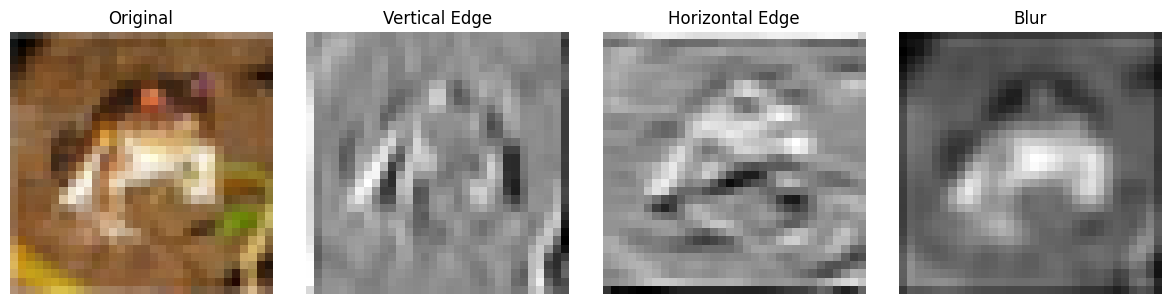

In [11]:
def show(ax, image, title):
    ax.imshow(image.squeeze().numpy(), cmap="gray")
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Original image
axes[0].imshow(img.squeeze().permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis("off")

show(axes[1], out_v, "Vertical Edge")
show(axes[2], out_h, "Horizontal Edge")
show(axes[3], out_b, "Blur")

plt.tight_layout()
plt.show()

## what each filter is actually doing:

For the vertical edge detector, the filter basically scans the image looking for straight, up-and-down lines or borders. It works by comparing the pixels on the left to the ones on the right to see where the brightness suddenly changes.

The horizontal edge detector does the exact same thing, but for side-to-side lines. It compares the top and bottom pixels to spot horizontal boundaries in the image.

Finally, the blur filter acts exactly like it sounds—it softens the picture. It takes a little 3x3 block of pixels and just blends them together into an average. It is really useful for smoothing out harsh details or quieting down any background noise.

#### Part B — Shape tracking.



In [13]:
import torch
import torch.nn as nn

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv1(x)
        print("After conv1:", x.shape)

        x = self.pool1(x)
        print("After pool1:", x.shape)

        x = self.conv2(x)
        print("After conv2:", x.shape)

        x = self.pool2(x)
        print("After pool2:", x.shape)

        return x

In [14]:
x = torch.randn(8, 3, 32, 32)

model = TinyCNN()
out = model(x)

After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


| Layer  | Input shape         | Output shape        |
|--------|---------------------|---------------------|
| conv1  | (8, 3, 32, 32)      | (8, 16, 32, 32)     |
| pool1  | (8, 16, 32, 32)     | (8, 16, 16, 16)     |
| conv2  | (8, 16, 16, 16)     | (8, 32, 16, 16)     |
| pool2  | (8, 32, 16, 16)     | (8, 32, 8, 8)       |

# Task 2 — Train a Small CNN on CIFAR-10


In [15]:
import torch
import torch.nn as nn

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

In [16]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = CNNClassifier()
print("Total trainable parameters:", count_params(model))

Total trainable parameters: 1117354


In [17]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# train/val split
train_size = int(0.9 * len(train_set))
val_size = len(train_set) - train_size

train_data, val_data = random_split(train_set, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

def accuracy(preds, labels):
    _, predicted = torch.max(preds, 1)
    return (predicted == labels).sum().item() / labels.size(0)

for epoch in range(15):
    # TRAIN
    model.train()
    total_loss, total_acc = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy(out, y)

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(total_acc / len(train_loader))

    # VALIDATION
    model.eval()
    val_loss, val_acc = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            val_acc += accuracy(out, y)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc / len(val_loader))

    print(f"Epoch {epoch+1}/15 | "
          f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | "
          f"Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Epoch 1/15 | Train Loss: 1.4316 | Val Loss: 1.2721 | Train Acc: 0.4812 | Val Acc: 0.5572
Epoch 2/15 | Train Loss: 0.9888 | Val Loss: 0.9363 | Train Acc: 0.6517 | Val Acc: 0.6697
Epoch 3/15 | Train Loss: 0.8318 | Val Loss: 0.8382 | Train Acc: 0.7075 | Val Acc: 0.7004
Epoch 4/15 | Train Loss: 0.7471 | Val Loss: 0.8362 | Train Acc: 0.7362 | Val Acc: 0.7104
Epoch 5/15 | Train Loss: 0.6783 | Val Loss: 0.7904 | Train Acc: 0.7629 | Val Acc: 0.7197
Epoch 6/15 | Train Loss: 0.6245 | Val Loss: 0.7273 | Train Acc: 0.7812 | Val Acc: 0.7457
Epoch 7/15 | Train Loss: 0.5745 | Val Loss: 0.6939 | Train Acc: 0.7980 | Val Acc: 0.7531
Epoch 8/15 | Train Loss: 0.5314 | Val Loss: 0.7370 | Train Acc: 0.8113 | Val Acc: 0.7496
Epoch 9/15 | Train Loss: 0.4868 | Val Loss: 0.6542 | Train Acc: 0.8287 | Val Acc: 0.7764
Epoch 10/15 | Train Loss: 0.4550 | Val Loss: 0.6553 | Train Acc: 0.8397 | Val Acc: 0.7832
Epoch 11/15 | Train Loss: 0.4190 | Val Loss: 0.6758 | Train Acc: 0.8501 | Val Acc: 0.7775
Epoch 12/15 | Train

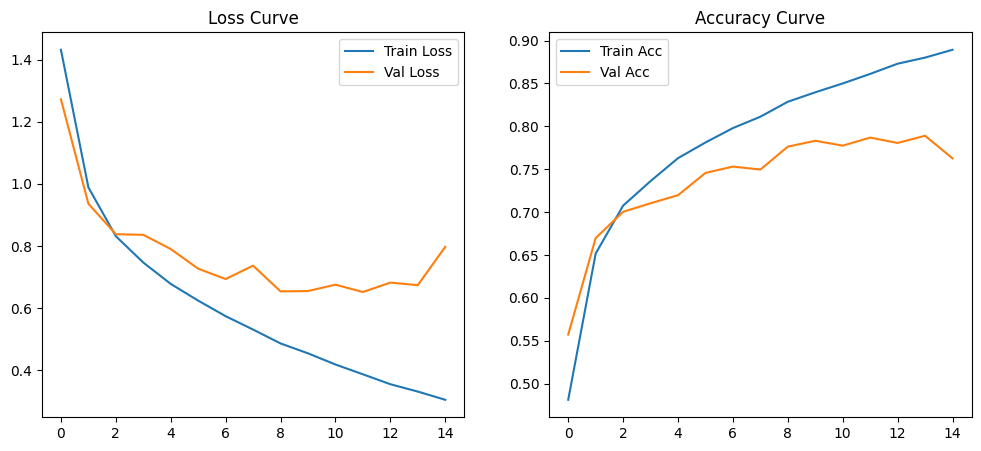

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

The graphs above display the model's training and validation metrics over 15 epochs. Looking at these charts, we can clearly observe a classic case of overfitting:

Loss Curve: The training loss (the blue line) decreases steadily as the epochs progress. However, while the validation loss (the orange line) drops initially, it bottoms out and starts to spike upward around epoch 10 to 12. This indicates that the model has stopped generalizing to new data and is just memorizing the training set.

Accuracy Curve: The training accuracy (the blue line) climbs continuously, reaching nearly 90%. In contrast, the validation accuracy (the orange line) plateaus around 78% and even dips slightly in the final epochs.

Conclusion: The growing gap between the training and validation metrics is clear proof that the model is overfitting. In the next step (Task 3), applying Data Augmentation will help prevent this issue and force the model to learn more robust features rather than memorizing exact pixels.

# Task 3 — Data Augmentation


In [21]:
import torchvision.transforms as transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

In [22]:
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

In [23]:
import torchvision
from torch.utils.data import DataLoader, random_split

train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_tf
)

test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=val_tf
)

# train/val split
train_size = int(0.9 * len(train_set))
val_size = len(train_set) - train_size

train_data, val_data = random_split(train_set, [train_size, val_size])

val_data.dataset.transform = val_tf  # VERY IMPORTANT FIX

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

In [24]:
model = CNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [25]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(15):
    model.train()
    total_loss, total_acc = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(out, 1)
        total_acc += (preds == y).float().mean().item()

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(total_acc / len(train_loader))

    # VALIDATION
    model.eval()
    val_loss, val_acc = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()

            _, preds = torch.max(out, 1)
            val_acc += (preds == y).float().mean().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc / len(val_loader))

    print(f"Epoch {epoch+1}/15 | "
          f"Train Acc: {train_accs[-1]:.4f} | "
          f"Val Acc: {val_accs[-1]:.4f}")

Epoch 1/15 | Train Acc: 0.4805 | Val Acc: 0.6047
Epoch 2/15 | Train Acc: 0.6459 | Val Acc: 0.6879
Epoch 3/15 | Train Acc: 0.7037 | Val Acc: 0.7246
Epoch 4/15 | Train Acc: 0.7348 | Val Acc: 0.7414
Epoch 5/15 | Train Acc: 0.7595 | Val Acc: 0.7139
Epoch 6/15 | Train Acc: 0.7777 | Val Acc: 0.7697
Epoch 7/15 | Train Acc: 0.7929 | Val Acc: 0.7721
Epoch 8/15 | Train Acc: 0.8100 | Val Acc: 0.7627
Epoch 9/15 | Train Acc: 0.8218 | Val Acc: 0.7865
Epoch 10/15 | Train Acc: 0.8361 | Val Acc: 0.7602
Epoch 11/15 | Train Acc: 0.8450 | Val Acc: 0.7789
Epoch 12/15 | Train Acc: 0.8543 | Val Acc: 0.7912
Epoch 13/15 | Train Acc: 0.8677 | Val Acc: 0.7986
Epoch 14/15 | Train Acc: 0.8725 | Val Acc: 0.7961
Epoch 15/15 | Train Acc: 0.8847 | Val Acc: 0.7965


| Run | Best val accuracy | Train/val gap (Final Epoch) |
| :--- | :--- | :--- |
| **Task 2 (no augmentation)** | 78.91% (Epoch 14) | 12.66% (88.93% - 76.27%) |
| **Task 3 (with augmentation)** | 79.86% (Epoch 13) | 8.82% (88.47% - 79.65%) |

By introducing data augmentation techniques like random cropping, horizontal flipping, and color adjustments, the model was exposed to a wider variety of visual patterns instead of seeing the exact same pixels in every epoch. This led to two major improvements.

First, it significantly reduced overfitting. The gap between the training and validation accuracy shrank from about 12.6% down to 8.8%. The validation loss also stabilized, whereas before it was sharply spiking at the end of training.

Second, it resulted in better generalization. Because the model could no longer rely on simply memorizing the training set, it had to actually learn more robust features. As a result, the best validation accuracy improved from 78.91% to 79.86%.

Ultimately, data augmentation made the model slightly slower to reach a really high training accuracy, but it made it much more reliable and accurate when evaluated on new, unseen data.